# Gabrielle Johnson's Week 5 Interim Deliverable

*Understanding Triage Patterns Through Data Analysis* 💻🔍



##1. Setup the Environment ⚙


In [127]:

import numpy as np    # numerical helpers
import pandas as pd   # tables / DataFrames
import matplotlib.pyplot as plt #plot graphs
import os
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


#pd.set_option("display.max_columns", 60)
#pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


## 2 · Dataset Loading 📈

*Reading the data's shape,columns and data types*

In [128]:
from pathlib import Path
from google.colab import drive
# mount Drive
drive.mount("/content/drive")
DATA_PATH = Path("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Place the CSV beside this notebook, or set DATA_PATH (Colab).")

# index_col=0 drops the unnamed export row-number column
df = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {df.shape[0]:,} ED encounters  x  {df.shape[1]} columns")

#inspecting the data
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 55,121 ED encounters  x  225 columns


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Creating A Schema Map 🧭
*A breakdown of the ~225 columns into groups that can be easily identifiable*

In [129]:
# ── Schema map ────────────────────────────────────────────────────────────────


TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least).
# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Helper: from a wish-list of names, keep only the ones that really exist in df.

    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # The ~200 chief-complaint columns all start with "cc_", so we find them by prefix:
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    fam = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return fam

###Column Audit 🔎

*This helps identify variables that may require type conversion, imputation, exclusion, or further clinical review before modelling.*

,Column Group,Column,Data Type,Non-Null Count,Missing Count,Missing Percentage
0,target,esi,float64,55121,0,0.0
1,vitals,triage_vital_hr,float64,55121,0,0.0
2,vitals,triage_vital_sbp,float64,55121,0,0.0
3,vitals,triage_vital_dbp,float64,55121,0,0.0
4,vitals,triage_vital_rr,float64,55121,0,0.0
5,vitals,triage_vital_o2,float64,55121,0,0.0
6,vitals,triage_vital_temp,float64,55121,0,0.0
7,vitals,triage_glucose,float64,55121,0,0.0
8,demographics,age,float64,55121,0,0.0
9,demographics,gender,object,55121,0,0.0


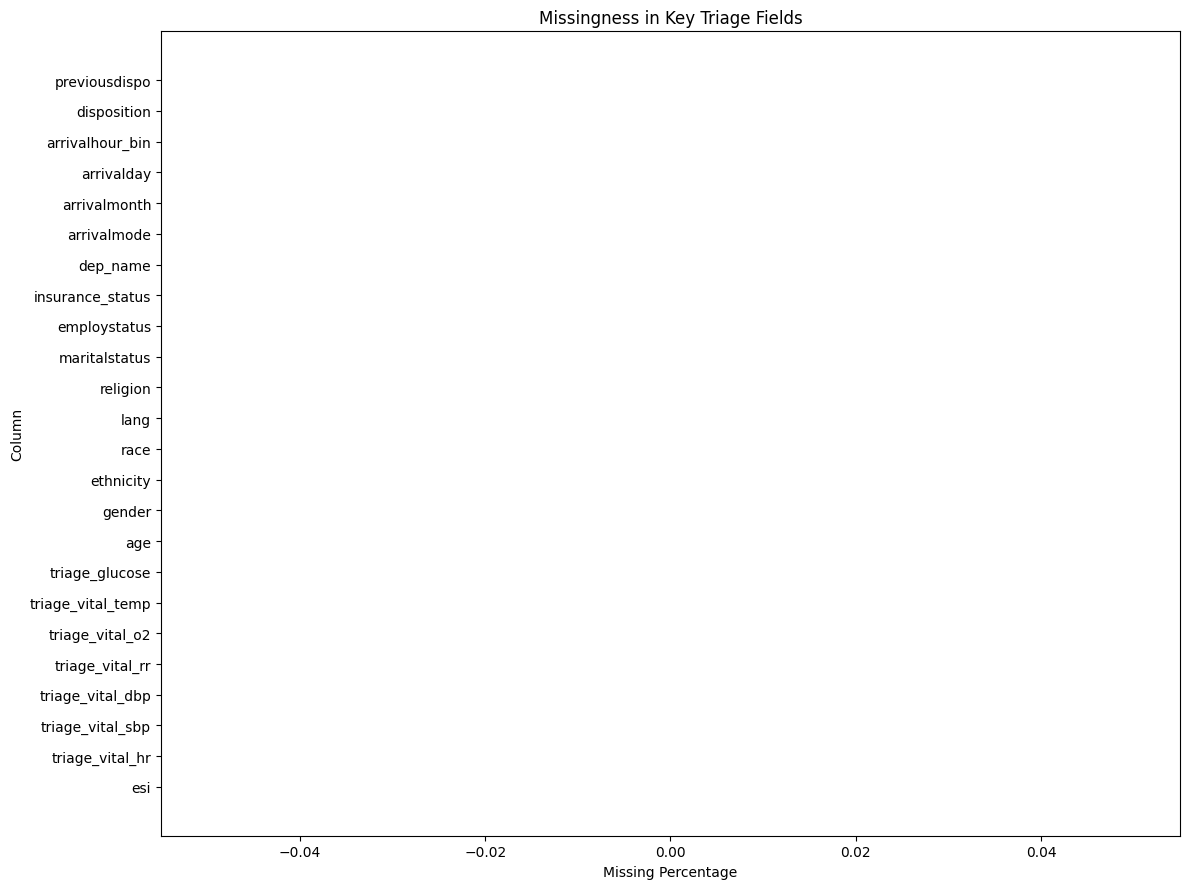

In [130]:

# look at each column's type and inspect the missingness of each column
dtype_audit = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Count": df.notna().sum().values,# ensure each column has data
    "Missing Count": df.isna().sum().values,
    "Missing Percentage": (df.isna().sum().values / len(df) * 100).round(2)
})

fam = classify_columns(df)

#exclude chief complaint columns from this review
missingness_fam = {
    group_name: columns
    for group_name, columns in fam.items()
    if group_name != "chief_complaints"
}

# Review missingness for target, vitals, demographics, admin, and leakage fields
missingness= []

for group_name, columns in missingness_fam.items():
    for col in columns:
        missingness.append({
            "Column Group": group_name,
            "Column": col,
            "Data Type": df[col].dtype,
            "Non-Null Count": df[col].notna().sum(),
            "Missing Count": df[col].isna().sum(),
            "Missing Percentage": round(df[col].isna().mean() * 100, 2)
        })

missingness = pd.DataFrame(missingness)

display(missingness)

# Plot missingness for the selected column
plot_data = missingness.sort_values("Missing Percentage", ascending=True).copy()

plot_data["Plot Label"] = plot_data["Column"]

fig, ax = plt.subplots(figsize=(12, 9))

ax.barh(
    plot_data["Plot Label"],
    plot_data["Missing Percentage"]
)

ax.set_title("Missingness in Key Triage Fields")
ax.set_xlabel("Missing Percentage")
ax.set_ylabel("Column")


plt.tight_layout()
plt.show()

##4.Demographic Breakdown
*Examining age groups and other patient characteristics relevant to triage patterns*

In [131]:
print("Demographic columns found in dataset:")
print(fam["demographics"])

if "age" in fam["demographics"]: #inspecting the age range of this dataset
    print("\nAGE:")
    print(df["age"].describe().round(1))
else:
    print("Age column not found.")

Demographic columns found in dataset:
['age', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status']

AGE:
count    55121.0
mean        55.3
std         19.5
min         18.0
25%         40.0
50%         55.0
75%         70.0
max        107.0
Name: age, dtype: float64


In [132]:
def assign_age_group(age):
  'Assign patient to an age group.This will later determine normal vital ranges'
  if pd.isna(age):
      return "Unknown"
  elif age < 18:
      return "Paediatric"
  elif age < 65:
      return "Adult"
  else:
      return "Elderly"

df["age_group"] = df["age"].apply(assign_age_group)
#print the age_group percentage, age is an important demographic that may influence esi levels
print((df["age_group"].value_counts(dropna=False, normalize=True)*100).round(2))

age_group
Adult      68.24
Elderly    31.76
Name: proportion, dtype: float64


In [133]:
# Reference ranges for general adult triage since there are no paediatric patients. Each entry is (low, high, unit).
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

*Cleaning the data before further evaluations* 🧼

In [134]:
def clean_triage(raw):
    """
    Takes the raw DataFrame and returns a cleaned copy.
    """
    d = raw.copy()
    fam = classify_columns(d)

    # Drop rows with no esi
    d = d[d[TARGET].notna()].copy()

    # Convert expected numeric fields to numeric
    numeric_cols = list(fam["vitals"])

    if "age" in d.columns:
        numeric_cols.append("age")

    if TARGET in d.columns:
        numeric_cols.append(TARGET)

    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # Drop rows where ESI became invalid after numeric conversion
    d = d[d[TARGET].notna()].copy()

    # Add impossible value flags only if implausible values exist
    for col, (low, high) in PLAUSIBLE.items():
      if col in d.columns:
        out_of_range = (d[col] < low) | (d[col] > high)

        # Only create the column if at least one impossible value exists
        if out_of_range.any():
            d[f"{col}_was_impossible"] = out_of_range.astype(int)

 # Add missingness flags only for vitals that have missing values
    for col in fam["vitals"]:
      if d[col].isna().sum() > 0:
        d[f"{col}_was_missing"] = d[col].isna().astype(int)
        d[col] = d[col].fillna(d[col].median())

    # Convert oxygen device flag to numeric.
    # assume a blank entry means no o2 device was recorded.
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = (
            pd.to_numeric(d["triage_vital_o2_device"], errors="coerce")
            .fillna(0)
        )

    # Clean chief complaint flags
    for col in fam["chief_complaints"]:
        d[col] = pd.to_numeric(d[col], errors="coerce").fillna(0)
        d[col] = d[col].apply(lambda x: 1 if x == 1 else 0)

    # Clean categorical text columns
    categorical_cols = fam["demographics"] + fam["admin"] + fam["leakage"]

    for col in categorical_cols:
        if col in d.columns and d[col].dtype == object:
            d[col] = d[col].astype(str).str.strip()
            d[col] = d[col].replace({
                "": "Unknown",
                "nan": "Unknown",
                "NaN": "Unknown",
                "None": "Unknown",
                "NONE": "Unknown"
            })
            d[col] = d[col].fillna("Unknown")

    #  Convert target to integer
    d[TARGET] = d[TARGET].round().astype(int)

    return d

In [135]:
df_clean = clean_triage(df)

#preview the difference between the old and cleaned dataset
print("Raw shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

raw_cols = set(df.columns)
clean_cols = set(df_clean.columns)
dropped_columns = sorted(raw_cols - clean_cols)
added_columns = sorted(clean_cols - raw_cols) #inspect the newly added columns after cleaning

print("Dropped columns:")
print(dropped_columns)
print("\nAdded columns:")
print(added_columns)
print('\n')

df_clean.head()

Raw shape: (55121, 226)
Cleaned shape: (55121, 228)
Dropped columns:
[]

Added columns:
['triage_glucose_was_impossible', 'triage_vital_rr_was_impossible']




,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain,age_group,triage_vital_rr_was_impossible,triage_glucose_was_impossible
7,A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0,0,0,0,0,0,0,Elderly,0,0
17,B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0,0,0,0,0,0,0,Adult,0,0
40,A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0,0,0,0,0,0,0,Adult,0,0
47,A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0,0,0,0,0,0,0,Adult,0,0
60,A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0,0,0,0,0,0,0,Adult,0,0


In [136]:
fam = classify_columns(df_clean)
# "structured" = the non-chief-complaint columns
structured = [col for col in df_clean.columns if not col.startswith("cc_")]
print(f"Number of structured columns found: {len(structured)}")
print(structured[:20])

Number of structured columns found: 28
['dep_name', 'esi', 'age', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status', 'disposition', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin', 'previousdispo', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp']


*Exploring the Demographic Distribution of the dataset 🧑*

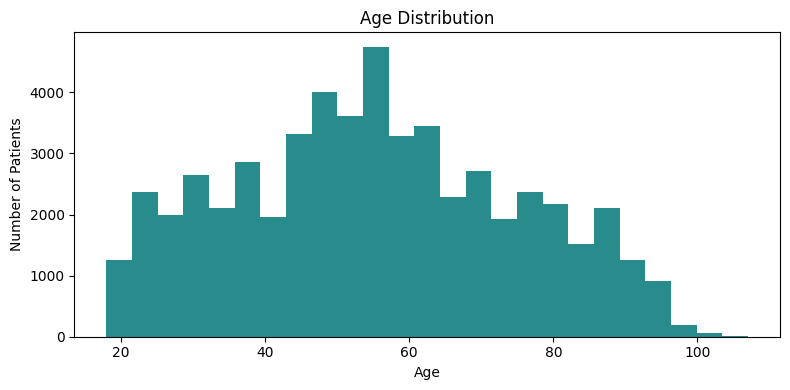

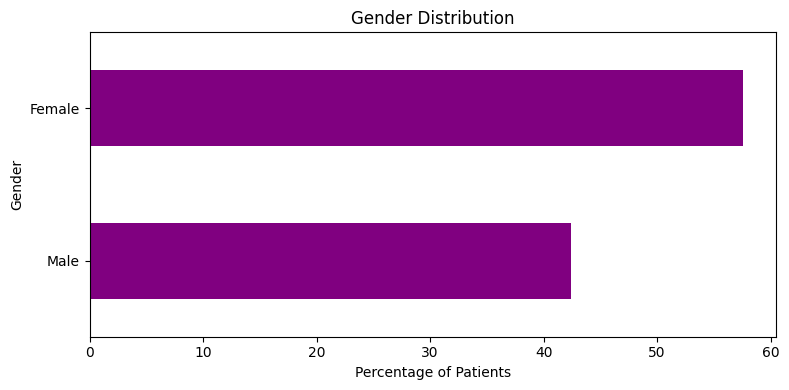

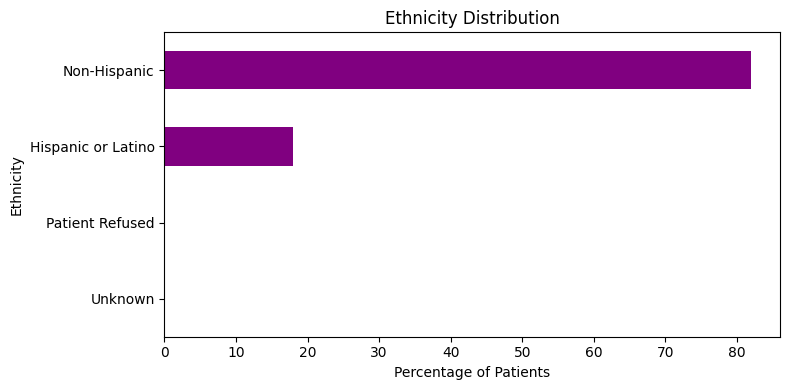

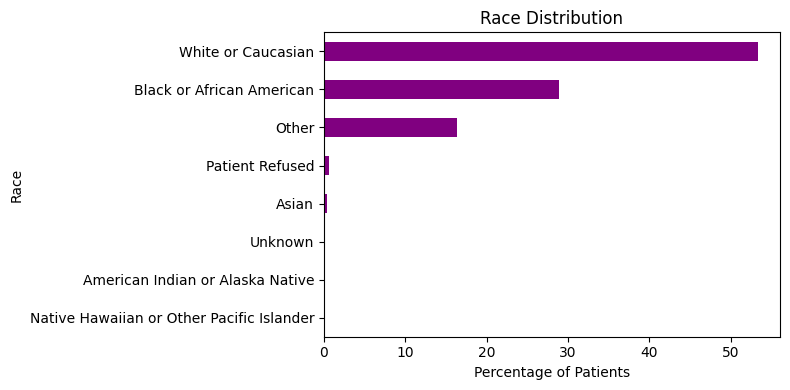

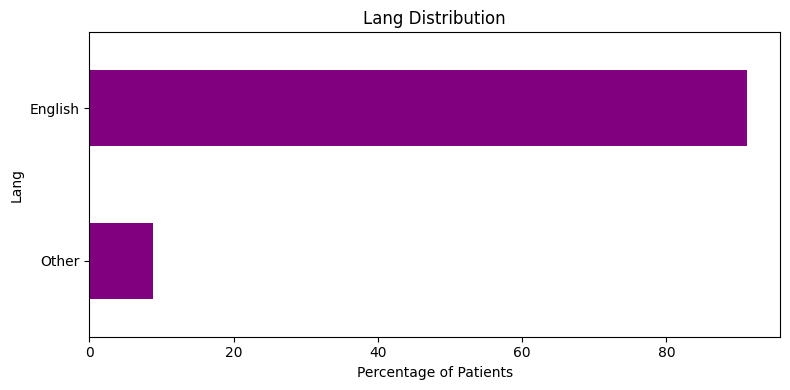

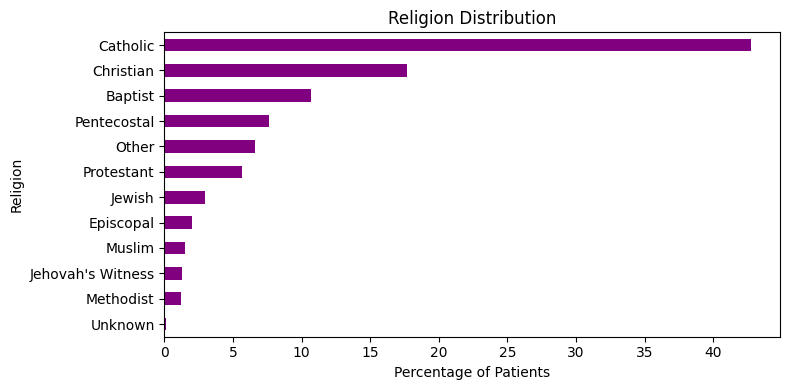

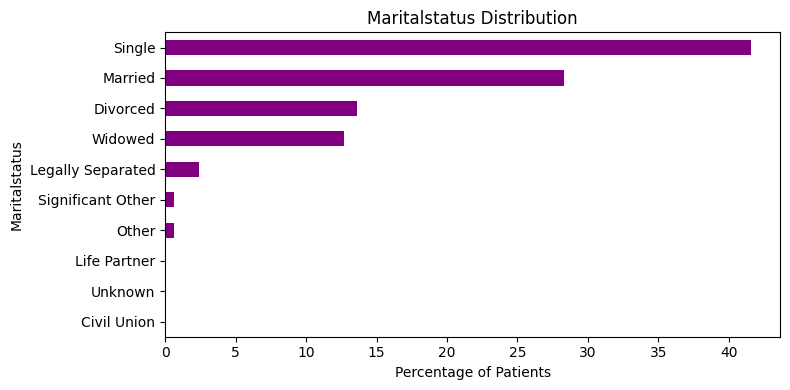

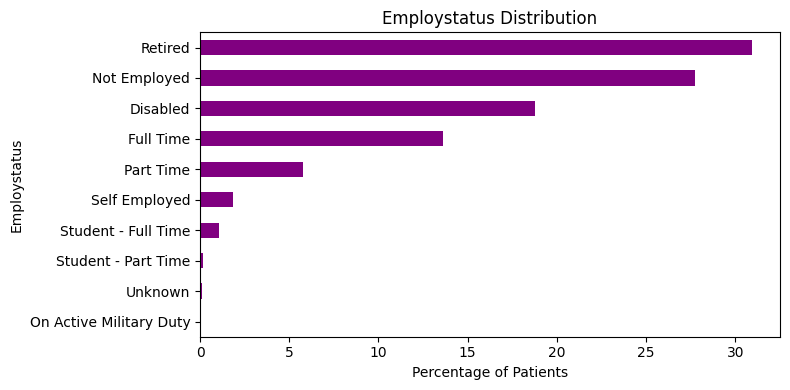

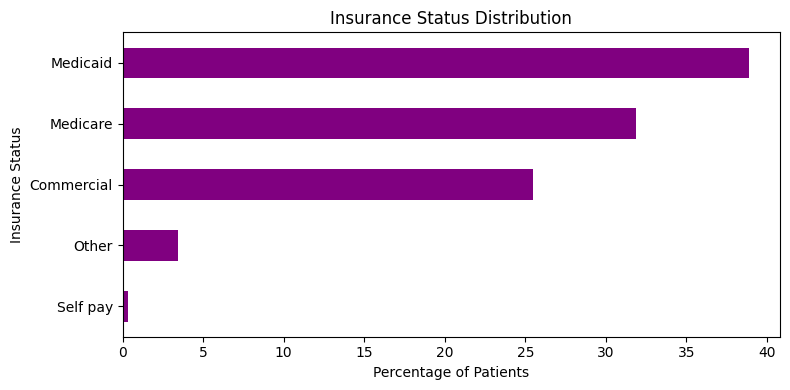

In [137]:
for col in fam["demographics"]:

    if pd.api.types.is_numeric_dtype(df_clean[col]): # if the column is numeric use a histogram
        fig, ax = plt.subplots(figsize=(8, 4))

        ax.hist(df_clean[col].dropna(), bins=25,color='#298c8c')

        ax.set_title(f"{col.replace('_', ' ').title()} Distribution")
        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_ylabel("Number of Patients")

        plt.tight_layout()
        plt.show()

    else:# for categorical data use horizontal bar charts
        percentages = (
            df_clean[col]
            .value_counts(dropna=False, normalize=True)
            .mul(100)
            .round(2)
        )

        fig, ax = plt.subplots(figsize=(8, 4))

        percentages.sort_values().plot.barh(ax=ax,color='purple')

        ax.set_title(f"{col.replace('_', ' ').title()} Distribution")
        ax.set_xlabel("Percentage of Patients")
        ax.set_ylabel(col.replace("_", " ").title())

        plt.tight_layout()
        plt.show()

In [138]:
#identify whether any demographic variable may skew fairness or interpretation.
demographic_skew_rows = []

for col in fam["demographics"]:

    # Numeric demographic variables do not have categories
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        demographic_skew_rows.append({
            "Column": col,
            "Type": "Numeric",
            "Most Common Category": "N/A",
            "Top Category Count": "N/A",
            "Top Category Percentage": "N/A",
        })

    else:
        counts = df_clean[col].value_counts(dropna=False)
        percentages = df_clean[col].value_counts(dropna=False, normalize=True) * 100

        demographic_skew_rows.append({
            "Column": col,
            "Type": "Categorical",
            "Most Common Category": counts.index[0],
            "Top Category Count": counts.iloc[0],
            "Top Category Percentage": round(percentages.iloc[0], 2),
        })

demographic_skew_summary = pd.DataFrame(demographic_skew_rows)

display(demographic_skew_summary)

,Column,Type,Most Common Category,Top Category Count,Top Category Percentage
0,age,Numeric,N/A,N/A,N/A
1,gender,Categorical,Female,31744,57.59
2,ethnicity,Categorical,Non-Hispanic,45142,81.9
3,race,Categorical,White or Caucasian,29435,53.4
4,lang,Categorical,English,50264,91.19
5,religion,Categorical,Catholic,23550,42.72
6,maritalstatus,Categorical,Single,22901,41.55
7,employstatus,Categorical,Retired,17058,30.95
8,insurance_status,Categorical,Medicaid,21427,38.87


##5.Exploring Correlations between Demographics and ESI 🩺

esi,1,2,3,4,5
age_group,,,,,
Adult,0.09,27.58,49.72,19.83,2.78
Elderly,0.26,43.12,47.45,8.20,0.97


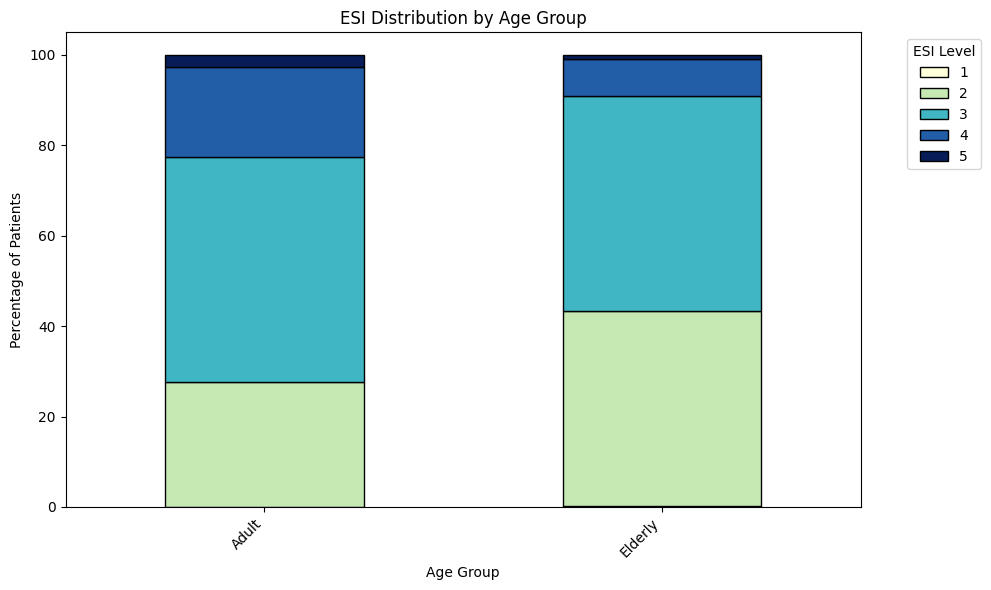

In [139]:
# is there a correlation between esi levels and age?
agegroup_esi = pd.crosstab(
    df_clean["age_group"],
    df_clean[TARGET],
    normalize="index"
) * 100

display(agegroup_esi.round(2))

# Stacked bar chart of esi levels by age group
fig, ax = plt.subplots(figsize=(10, 6))

agegroup_esi.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="YlGnBu",
    edgecolor="black"
)

ax.set_title("ESI Distribution by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Percentage of Patients")

ax.legend(
    title="ESI Level",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [140]:
# Spearman correlation between age and ESI
# does esi levels decrease and age increases?
age_esi_corr = df_clean[["age", TARGET]].corr(method="spearman").iloc[0, 1]

print(f"Spearman correlation between age and ESI: {age_esi_corr:.3f}")

Spearman correlation between age and ESI: -0.238


ESI DISTRIBUTION WITHIN GENDER GROUPS


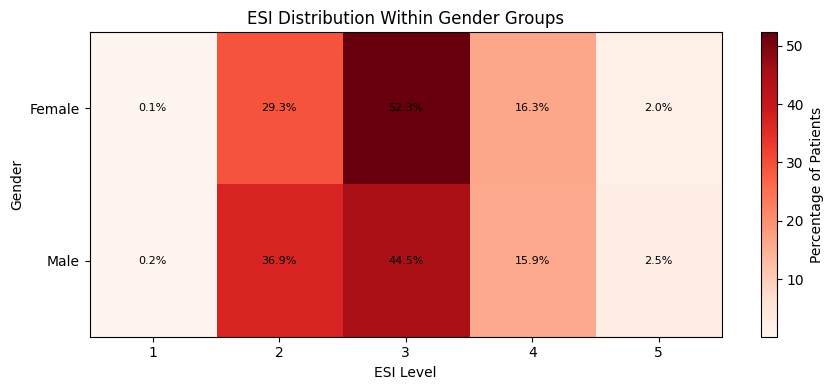

ESI DISTRIBUTION WITHIN ETHNICITY GROUPS


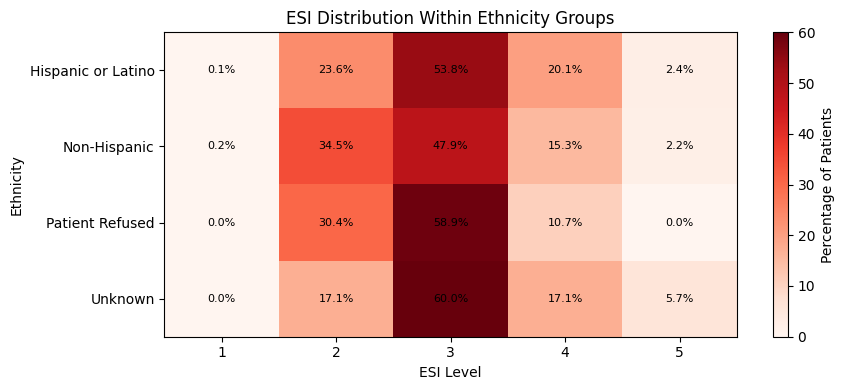

ESI DISTRIBUTION WITHIN RACE GROUPS


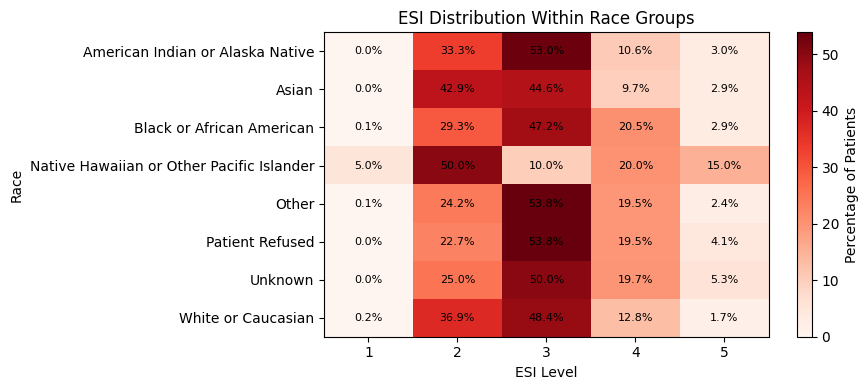

ESI DISTRIBUTION WITHIN LANG GROUPS


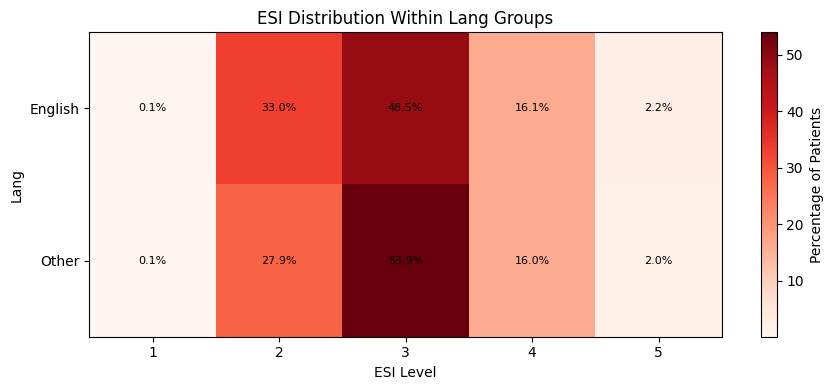

ESI DISTRIBUTION WITHIN RELIGION GROUPS


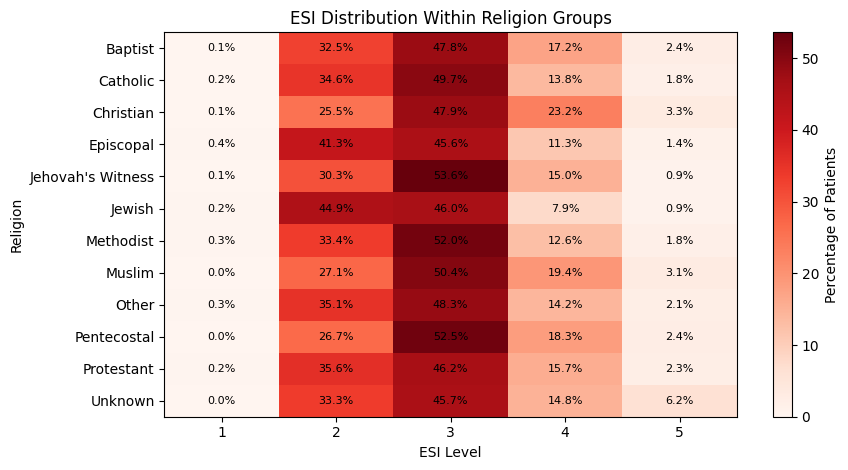

ESI DISTRIBUTION WITHIN MARITALSTATUS GROUPS


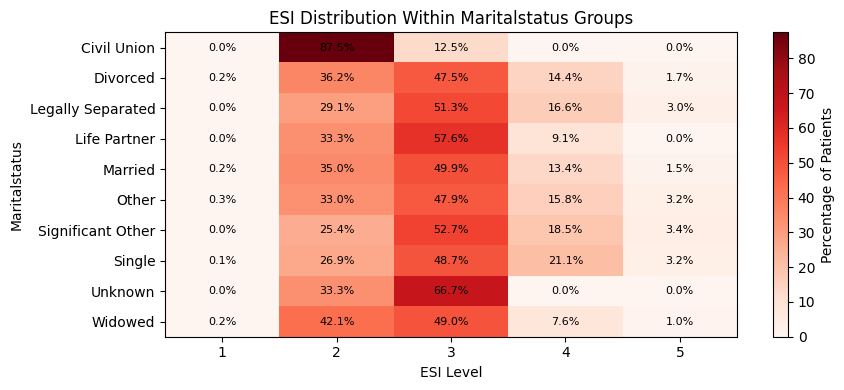

ESI DISTRIBUTION WITHIN EMPLOYSTATUS GROUPS


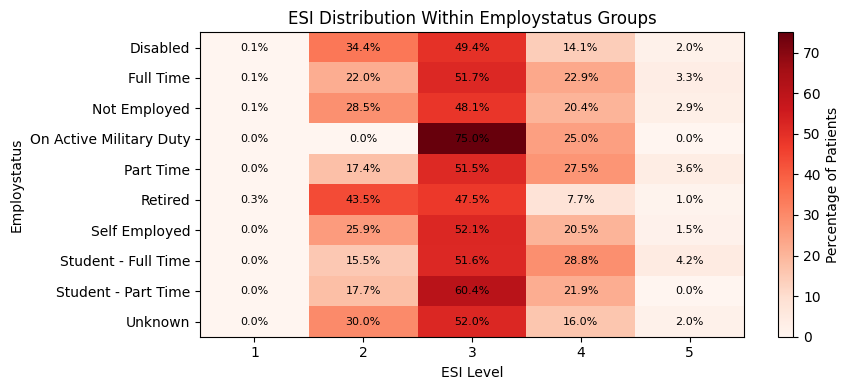

ESI DISTRIBUTION WITHIN INSURANCE_STATUS GROUPS


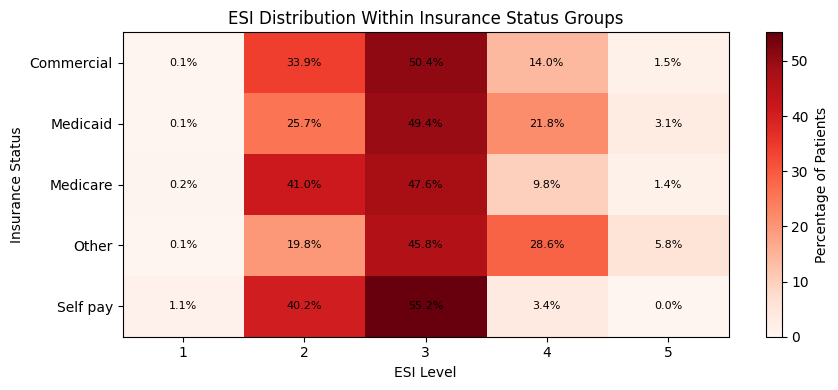

In [141]:
for col in fam["demographics"]:

    if col == "age":
        continue
#looking at the correlation between categorical columns and esi levels
    if not pd.api.types.is_numeric_dtype(df_clean[col]):

        print("=" * 80)
        print(f"ESI DISTRIBUTION WITHIN {col.upper()} GROUPS")

        demo_esi_pct = pd.crosstab(
            df_clean[col],
            df_clean[TARGET],
            normalize="index"
        ) * 100

        fig, ax = plt.subplots(figsize=(9, max(4, len(demo_esi_pct) * 0.4)))

        im = ax.imshow(demo_esi_pct, aspect="auto", cmap="Reds")

        ax.set_title(f"ESI Distribution Within {col.replace('_', ' ').title()} Groups")
        ax.set_xlabel("ESI Level")
        ax.set_ylabel(col.replace("_", " ").title())

        ax.set_xticks(range(len(demo_esi_pct.columns)))
        ax.set_xticklabels(demo_esi_pct.columns)

        ax.set_yticks(range(len(demo_esi_pct.index)))
        ax.set_yticklabels(demo_esi_pct.index)

        # Write percentage values inside each heatmap cell
        for i in range(len(demo_esi_pct.index)):
            for j in range(len(demo_esi_pct.columns)):
                value = demo_esi_pct.iloc[i, j]
                ax.text(
                    j,
                    i,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8
                )

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Percentage of Patients")

        plt.tight_layout()
        plt.show()

##6. Exploring Vitals 🫀




In [142]:
vital_summary = df_clean[fam["vitals"]].describe().round(2)

display(vital_summary)

,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_temp,triage_glucose
count,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00,55121.00
mean,86.45,133.68,79.53,17.84,97.02,98.09,130.09
std,16.96,22.65,14.59,2.07,2.08,0.81,73.66
min,32.00,53.00,27.00,8.00,62.00,91.50,16.00
25%,74.00,118.00,70.00,16.00,96.00,97.70,93.00
50%,85.00,132.00,79.00,18.00,98.00,98.00,107.00
75%,97.00,147.00,89.00,18.00,98.00,98.40,134.00
max,221.00,266.00,189.00,66.00,99.00,106.00,1066.00


*Exploring Normal and Abnormal Vital Ranges* 🫁

In [143]:
#secondary check to ensure there are rows with clinically implausible data
vital_plausibility_rows = []

for col in fam["vitals"]:
    if col in PLAUSIBLE:
        low, high = PLAUSIBLE[col] #looking at clinically pausible high and low values for each vital sign

        numeric_col = pd.to_numeric(df_clean[col], errors="coerce")

        vital_plausibility_rows.append({
            "Vital Sign": col,
            "Plausible Low": low,
            "Plausible High": high,
            "Minimum Found": numeric_col.min(),#is the min value found lower than what is clinically plausible
            "Maximum Found": numeric_col.max()#is the max value found higher than what is clinically plausible
        })

vital_plausibility_audit = pd.DataFrame(vital_plausibility_rows)

display(vital_plausibility_audit)

,Vital Sign,Plausible Low,Plausible High,Minimum Found,Maximum Found
0,triage_vital_hr,20,250,32.0,221.0
1,triage_vital_sbp,50,300,53.0,266.0
2,triage_vital_dbp,20,200,27.0,189.0
3,triage_vital_rr,4,60,8.0,66.0
4,triage_vital_o2,50,100,62.0,99.0
5,triage_vital_temp,86,110,91.5,106.0
6,triage_glucose,20,800,16.0,1066.0


In [144]:
# Create a table showing which patient rows have implausible vital values
# and which chief complaint flags are present for that patient

cc_cols = [col for col in df_clean.columns if col.startswith("cc_")]

implausible_rows = []

for col in fam["vitals"]:
    if col in PLAUSIBLE and col in df_clean.columns:
        low, high = PLAUSIBLE[col]

        numeric_col = pd.to_numeric(df_clean[col], errors="coerce")
        out_of_range = (numeric_col < low) | (numeric_col > high)

        for idx in df_clean.index[out_of_range]:

            active_complaints = [
                cc for cc in cc_cols
                if df_clean.loc[idx, cc] == 1
            ]

            implausible_rows.append({
                "Row Index": idx,
                "Vital Sign": col,
                "Value Found": df_clean.loc[idx, col],
                "Plausible Low": low,
                "Plausible High": high,
                "ESI": df_clean.loc[idx, "esi"] if "esi" in df_clean.columns else None,
                "Active Chief Complaints": ", ".join(active_complaints) if active_complaints else "No chief complaint flag"
            })

implausible_patient_audit = pd.DataFrame(implausible_rows)

display(implausible_patient_audit)

,Row Index,Vital Sign,Value Found,Plausible Low,Plausible High,ESI,Active Chief Complaints
0,4842,triage_vital_rr,63.0,4,60,4,cc_kneepain
1,81040,triage_vital_rr,66.0,4,60,3,cc_abscess
2,148127,triage_vital_rr,62.0,4,60,2,cc_chestpain
3,274497,triage_vital_rr,64.0,4,60,3,cc_backpain
4,9864,triage_glucose,876.0,20,800,3,cc_chestpain
5,57584,triage_glucose,19.0,20,800,2,cc_abdominalpain
6,73429,triage_glucose,833.0,20,800,2,cc_chestpain
7,84886,triage_glucose,936.0,20,800,3,"cc_abdominalpain, cc_elevatedbloodsugar-sympto..."
8,84918,triage_glucose,818.0,20,800,2,cc_elevatedbloodsugar-symptomatic
9,84934,triage_glucose,874.0,20,800,3,cc_abdominalpain


In [145]:
# IQR outliers for vitals
#how many patients are statistical outliers?

outlier_rows = []

numeric_check_cols = fam["vitals"]

for col in numeric_check_cols:
    if col in df_clean.columns:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = df_clean[
            (df_clean[col] < lower_bound) |
            (df_clean[col] > upper_bound)
        ]#exploring how many patients are outliers of the dataset

        outlier_rows.append({
            "Column": col,
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "IQR": round(iqr, 2),
            "Lower Bound": round(lower_bound, 2),
            "Upper Bound": round(upper_bound, 2),
            "Outlier Count": len(outliers),
            "Outlier Percentage": round(len(outliers) / len(df_clean) * 100, 2)
        })

iqr_outlier_summary = pd.DataFrame(outlier_rows)

display(iqr_outlier_summary)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,triage_vital_hr,74.0,97.0,23.0,39.50,131.50,578,1.05
1,triage_vital_sbp,118.0,147.0,29.0,74.50,190.50,1028,1.86
2,triage_vital_dbp,70.0,89.0,19.0,41.50,117.50,726,1.32
3,triage_vital_rr,16.0,18.0,2.0,13.00,21.00,2366,4.29
4,triage_vital_o2,96.0,98.0,2.0,93.00,101.00,1505,2.73
5,triage_vital_temp,97.7,98.4,0.7,96.65,99.45,3554,6.45
6,triage_glucose,93.0,134.0,41.0,31.50,195.50,5673,10.29


In [146]:
normal_range_rows = []

for col in fam["vitals"]:
    if col in NORMAL_RANGES:
        low, high, unit = NORMAL_RANGES[col]

        numeric_col = pd.to_numeric(df_clean[col], errors="coerce")
        below_normal = numeric_col < low
        above_normal = numeric_col > high
        outside_normal = below_normal | above_normal

        normal_range_rows.append({
            "Vital Sign": col,
            "Normal Low": low,
            "Normal High": high,
            "Below Normal Count": int(below_normal.sum()),
            "Above Normal Count": int(above_normal.sum()),
            "Outside Normal Count": int(outside_normal.sum()),
            "Outside Normal Percentage": round(outside_normal.mean() * 100, 2)# looking at how many patietns are outside of the clinically normal ranges for each vital sign
        })

normal_range_audit = pd.DataFrame(normal_range_rows)

display(normal_range_audit)

,Vital Sign,Normal Low,Normal High,Below Normal Count,Above Normal Count,Outside Normal Count,Outside Normal Percentage
0,triage_vital_hr,60.0,100.0,1857,10404,12261,22.24
1,triage_vital_sbp,90.0,140.0,594,18925,19519,35.41
2,triage_vital_dbp,60.0,90.0,4173,11533,15706,28.49
3,triage_vital_rr,12.0,20.0,15,2349,2364,4.29
4,triage_vital_o2,95.0,100.0,4839,0,4839,8.78
5,triage_vital_temp,97.0,99.5,2367,1973,4340,7.87
6,triage_glucose,70.0,140.0,647,12228,12875,23.36


*Exploring the Distributions of Vital Signs amongst patients* 🧠

---



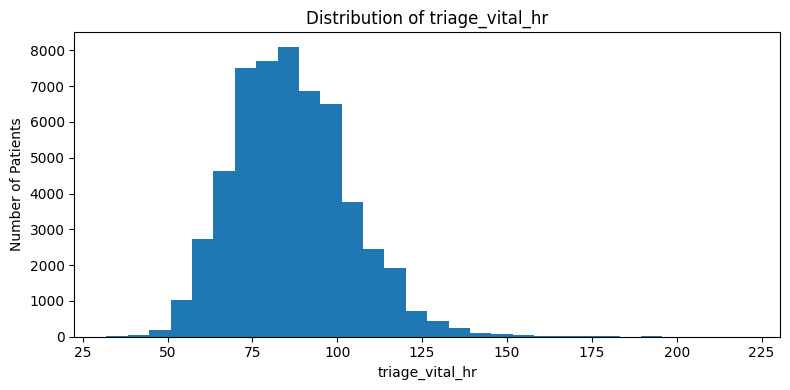

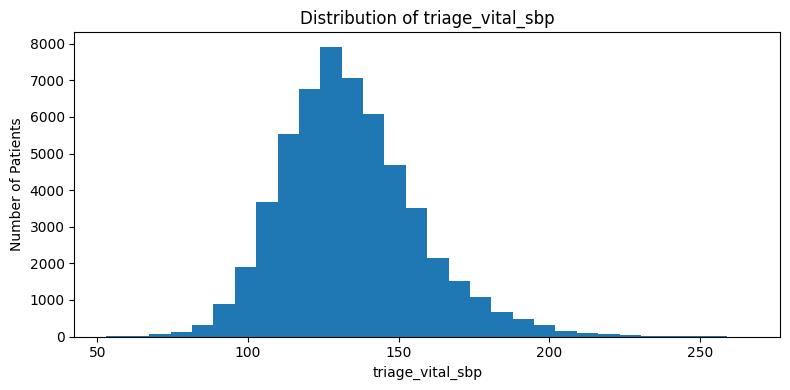

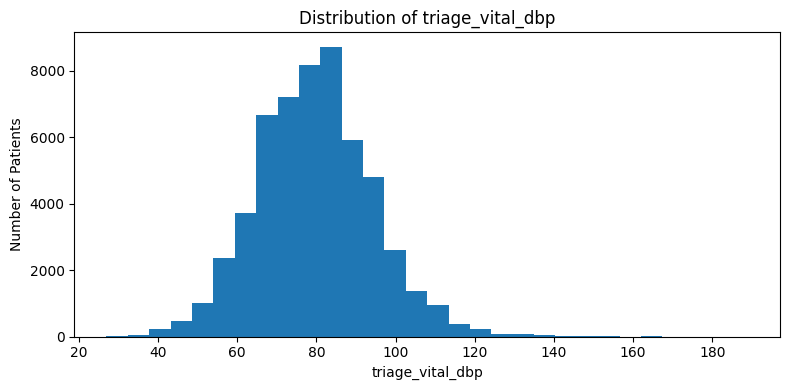

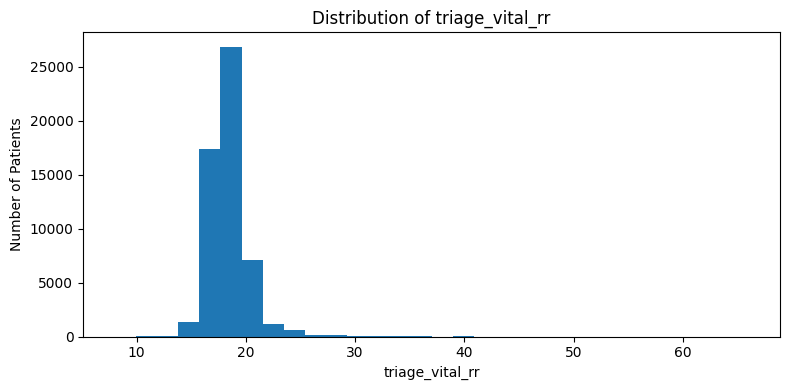

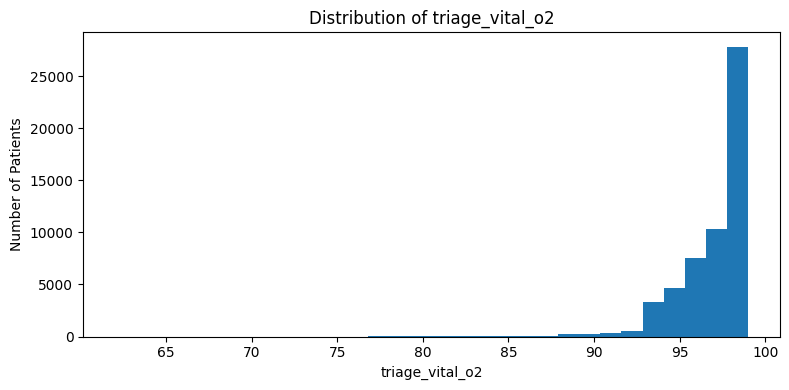

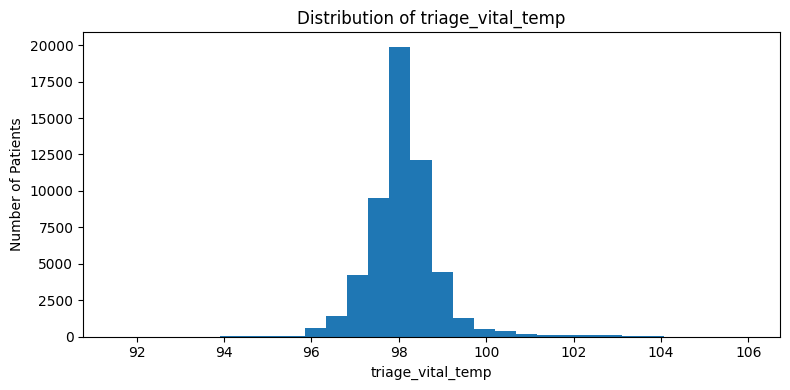

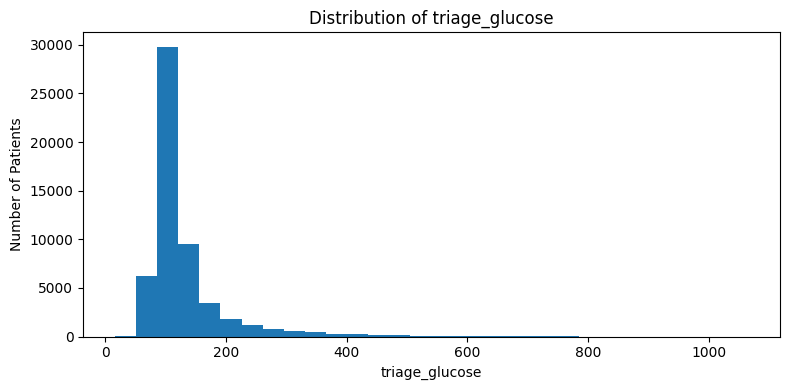

In [147]:
for col in fam["vitals"]:
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.hist(df_clean[col].dropna(), bins=30)

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of Patients")

    plt.tight_layout()
    plt.show()

*Exploring the Correlation Between ESI and Vital Signs*

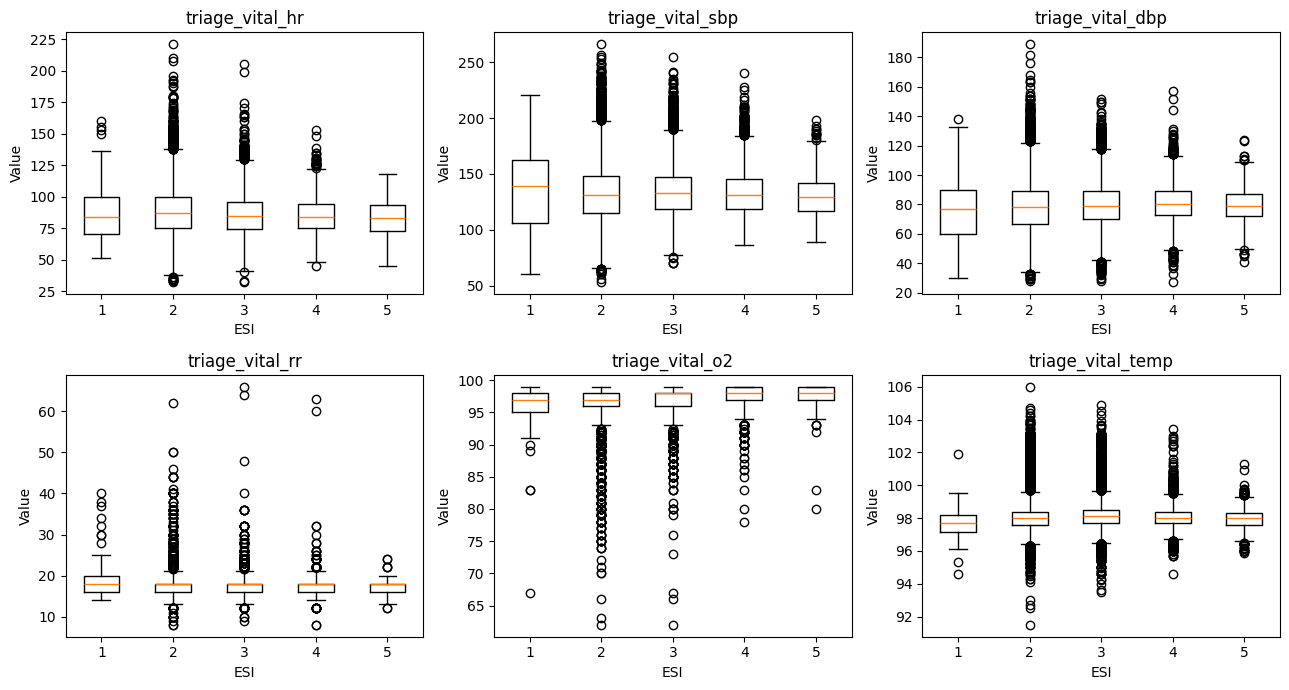

In [148]:
vitals_to_plot = fam["vitals"][:6]

esi_levels = sorted(df_clean[TARGET].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for panel, col in zip(axes.ravel(), vitals_to_plot):
    groups = []

    for level in esi_levels:
        values = df_clean.loc[df_clean[TARGET] == level, col].dropna()
        groups.append(values)

    panel.boxplot(groups, tick_labels=esi_levels)
    panel.set_title(col)
    panel.set_xlabel("ESI")
    panel.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [149]:
#as vitals increase/decrease how does it influence esi levels?
spearman_vital_esi_rows = []

for vital in fam["vitals"]:

    # Calculate Spearman correlation between each vital sign and ESI
    corr_value = df_clean[[vital, TARGET]].corr(method="spearman").iloc[0, 1]

    spearman_vital_esi_rows.append({
        "Vital Sign": vital,
        "Spearman Correlation": round(corr_value, 3)

    })

spearman_vital_esi = (
    pd.DataFrame(spearman_vital_esi_rows)
    .sort_values("Spearman Correlation", ascending=False)
)

display(spearman_vital_esi)

,Vital Sign,Spearman Correlation
4,triage_vital_o2,0.159
2,triage_vital_dbp,0.061
1,triage_vital_sbp,0.020
5,triage_vital_temp,0.010
3,triage_vital_rr,-0.056
0,triage_vital_hr,-0.073
6,triage_glucose,-0.111


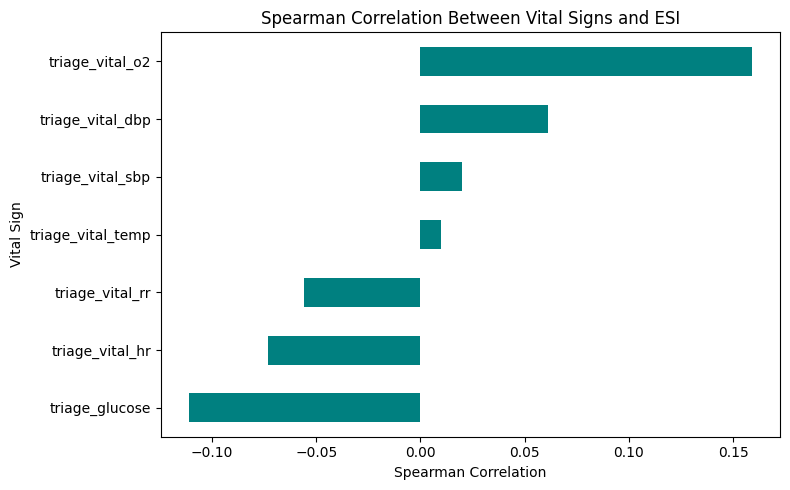

In [150]:
fig, ax = plt.subplots(figsize=(8, 5))

spearman_vital_esi.sort_values("Spearman Correlation").plot.barh(
    x="Vital Sign",
    y="Spearman Correlation",
    ax=ax,
    color='teal',
    legend=False
)

ax.set_title("Spearman Correlation Between Vital Signs and ESI")
ax.set_xlabel("Spearman Correlation")
ax.set_ylabel("Vital Sign")

plt.tight_layout()
plt.show()


In [151]:
#exploring the correlation of vitals with each other
vital_corr = df_clean[fam["vitals"]].corr()

display(vital_corr.round(2))

,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_temp,triage_glucose
triage_vital_hr,1.00,-0.04,0.18,0.14,-0.07,0.21,0.05
triage_vital_sbp,-0.04,1.00,0.63,0.06,0.02,-0.01,0.10
triage_vital_dbp,0.18,0.63,1.00,0.04,0.08,-0.01,0.01
triage_vital_rr,0.14,0.06,0.04,1.00,-0.16,0.07,0.02
triage_vital_o2,-0.07,0.02,0.08,-0.16,1.00,-0.07,-0.05
triage_vital_temp,0.21,-0.01,-0.01,0.07,-0.07,1.00,-0.00
triage_glucose,0.05,0.10,0.01,0.02,-0.05,-0.00,1.00


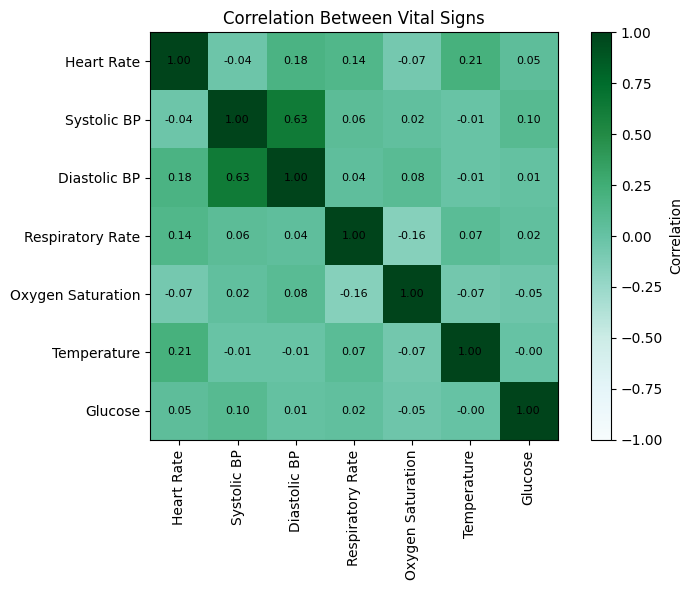

In [152]:
vital_labels = {
    "triage_vital_hr": "Heart Rate",
    "triage_vital_sbp": "Systolic BP",
    "triage_vital_dbp": "Diastolic BP",
    "triage_vital_rr": "Respiratory Rate",
    "triage_vital_o2": "Oxygen Saturation",
    "triage_vital_temp": "Temperature",
    "triage_glucose": "Glucose"
}#easier reading of vital signs

vital_cols = fam["vitals"]
vital_corr = df_clean[vital_cols].corr()

clean_labels = [vital_labels.get(col, col) for col in vital_corr.columns]

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(vital_corr, cmap="BuGn", vmin=-1, vmax=1)

ax.set_title("Correlation Between Vital Signs")

ax.set_xticks(range(len(clean_labels)))
ax.set_xticklabels(clean_labels, rotation=90)

ax.set_yticks(range(len(clean_labels)))
ax.set_yticklabels(clean_labels)

for i in range(len(vital_corr.index)):
    for j in range(len(vital_corr.columns)):
        value = vital_corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlation")

plt.tight_layout()
plt.show()

##7.Exploring Cheif Complaints ☢

In [153]:
cc_cols = fam["chief_complaints"]

print(f"Number of chief complaint columns found: {len(cc_cols)}")
print(cc_cols[:20])

Number of chief complaint columns found: 200
['cc_abdominalcramping', 'cc_abdominaldistention', 'cc_abdominalpain', 'cc_abdominalpainpregnant', 'cc_abnormallab', 'cc_abscess', 'cc_addictionproblem', 'cc_agitation', 'cc_alcoholintoxication', 'cc_alcoholproblem', 'cc_allergicreaction', 'cc_alteredmentalstatus', 'cc_animalbite', 'cc_ankleinjury', 'cc_anklepain', 'cc_anxiety', 'cc_arminjury', 'cc_armpain', 'cc_armswelling', 'cc_assaultvictim']


In [154]:
#ensuring CC only contain 1 or 0
non_binary_cc = []

for col in cc_cols:
    values = set(df_clean[col].dropna().unique())

    if not values.issubset({0, 1, 0.0, 1.0}):
        non_binary_cc.append({
            "Column": col,
            "Unique Values": sorted(values)
        })

non_binary_cc_df = pd.DataFrame(non_binary_cc)

display(non_binary_cc_df)

""


In [155]:
#exploring the most populous cheif complaints
chief_complaint_counts = (
    df_clean[cc_cols]
    .sum()
    .sort_values(ascending=False)
)

chief_complaint_percentages = (
    chief_complaint_counts / len(df_clean) * 100
).round(2)

chief_complaint_summary = pd.DataFrame({
    "Count": chief_complaint_counts,
    "Percentage": chief_complaint_percentages
})

display(chief_complaint_summary.head(20))

,Count,Percentage
cc_abdominalpain,6715,12.18
cc_other,4338,7.87
cc_chestpain,3710,6.73
cc_shortnessofbreath,3098,5.62
cc_backpain,1997,3.62
cc_fall,1922,3.49
cc_cough,1439,2.61
cc_dizziness,1292,2.34
cc_legpain,1264,2.29
cc_emesis,1249,2.27


In [156]:
#Number of chief complaints per patient
cc_cols = fam["chief_complaints"]

df_clean["num_chief_complaints"] = df_clean[fam["chief_complaints"]].sum(axis=1)

print("Number of chief complaints per patient:")
display(df_clean["num_chief_complaints"].value_counts().sort_index())


Number of chief complaints per patient:


,count
num_chief_complaints,
0,54
1,47947
2,6289
3,737
4,81
5,11
6,2


In [157]:
#Number of chief complaints per patient
#Percentage of the number of CC per patient
complaint_count_summary = pd.DataFrame({
    "Count": df_clean["num_chief_complaints"].value_counts().sort_index(),
    "Percentage": (
        df_clean["num_chief_complaints"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

display(complaint_count_summary)

,Count,Percentage
num_chief_complaints,,
0,54,0.10
1,47947,86.98
2,6289,11.41
3,737,1.34
4,81,0.15
5,11,0.02
6,2,0.00


In [158]:
# Identify patients with no chief complaint
no_cc_mask = df_clean[cc_cols].sum(axis=1) == 0

no_cc_patients = df_clean.loc[no_cc_mask].copy()

print(f"Number of patients with no chief complaint: {len(no_cc_patients)}")
print(f"Percentage of dataset: {round(len(no_cc_patients) / len(df_clean) * 100, 2)}%")

Number of patients with no chief complaint: 54
Percentage of dataset: 0.1%


In [159]:
#display patients with no chief complaint
no_cc_cols_to_view = ["esi"] + fam["vitals"]

no_cc_esi_vitals = no_cc_patients[no_cc_cols_to_view].copy()

display(no_cc_esi_vitals)

,esi,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_temp,triage_glucose
2361,3,80.0,112.0,78.0,16.0,98.0,98.0,109.0
8127,4,83.0,140.0,80.0,14.0,99.0,96.8,111.0
12898,4,101.0,156.0,101.0,20.0,98.0,98.3,95.0
13433,3,54.0,126.0,87.0,16.0,99.0,97.9,121.0
14928,4,64.0,125.0,81.0,18.0,98.0,97.9,101.0
22989,2,110.0,123.0,87.0,16.0,98.0,97.3,88.0
24581,3,102.0,115.0,72.0,16.0,96.0,99.3,71.0
24980,2,82.0,146.0,79.0,18.0,99.0,97.2,149.0
29132,4,125.0,124.0,85.0,18.0,99.0,98.4,108.0
36488,3,120.0,153.0,108.0,23.0,98.0,97.0,112.0


In [160]:
# are there abnormal vitals for patients with no CCs

def get_abnormal_vitals(row): # this function displays the abnormal vital a patient with no CCs has
    abnormal_vitals = []

    for col, (low, high, unit) in NORMAL_RANGES.items():
        if col in row.index:
            value = pd.to_numeric(row[col], errors="coerce")

            if pd.notna(value) and ((value < low) or (value > high)):
                abnormal_vitals.append(
                    f"{col}: {value} {unit}"
                )

    return ", ".join(abnormal_vitals) if abnormal_vitals else None


no_cc_patients["abnormal_vitals"] = no_cc_patients.apply(get_abnormal_vitals, axis=1)

vital_cols = [
    col for col in NORMAL_RANGES
    if col in no_cc_patients.columns
]

no_cc_vital_audit = no_cc_patients[
    ["esi"] + ["abnormal_vitals"]
].copy()

display(no_cc_vital_audit)

,esi,abnormal_vitals
2361,3,None
8127,4,triage_vital_temp: 96.8 F
12898,4,"triage_vital_hr: 101.0 bpm, triage_vital_sbp: ..."
13433,3,triage_vital_hr: 54.0 bpm
14928,4,None
22989,2,triage_vital_hr: 110.0 bpm
24581,3,triage_vital_hr: 102.0 bpm
24980,2,"triage_vital_sbp: 146.0 mmHg, triage_glucose: ..."
29132,4,triage_vital_hr: 125.0 bpm
36488,3,"triage_vital_hr: 120.0 bpm, triage_vital_sbp: ..."


*Exploring the correlation amongst CCs*

In [161]:
# which CCs are paired with each other?
cc_cols = fam["chief_complaints"]


# Co-occurrence matrix:
# each cell shows how many patients had both complaints
cc_cooccurrence = df_clean[cc_cols].T.dot(df_clean[cc_cols])


cooccurrence_pairs = []

for i, col1 in enumerate(cc_cols):
    for col2 in cc_cols[i + 1:]:
        count = cc_cooccurrence.loc[col1, col2]

        if count > 0:
            cooccurrence_pairs.append({
                "Complaint 1": col1,
                "Complaint 2": col2,
                "Co-occurrence Count": int(count)
            })

cooccurrence_pairs = pd.DataFrame(cooccurrence_pairs)

cooccurrence_pairs = cooccurrence_pairs.sort_values(
    "Co-occurrence Count",
    ascending=False
)

display(cooccurrence_pairs.head(20))

,Complaint 1,Complaint 2,Co-occurrence Count
67,cc_abdominalpain,cc_emesis,206
882,cc_chestpain,cc_shortnessofbreath,155
1084,cc_cough,cc_shortnessofbreath,134
1530,cc_emesis,cc_nausea,101
46,cc_abdominalpain,cc_chestpain,101
109,cc_abdominalpain,cc_nausea,98
1203,cc_diarrhea,cc_emesis,95
57,cc_abdominalpain,cc_diarrhea,93
336,cc_alcoholintoxication,cc_suicidal,74
113,cc_abdominalpain,cc_other,71


In [162]:
# Conditional probability: P(Complaint B | Complaint A)
conditional_prob = pd.DataFrame(index=cc_cols, columns=cc_cols, dtype=float)

#display conditional probabilities
conditional_pairs = []

for col1 in cc_cols:
    for col2 in cc_cols:
        if col1 != col2:
            prob = conditional_prob.loc[col1, col2]

            # Number of patients who had the first complaint
            support = int((df_clean[col1] == 1).sum())

            if prob > 0:
                conditional_pairs.append({
                    "If Patient Has": col1,
                    "Also Has": col2,
                    "Probability (%)": round(prob, 2),
                    "Patients With First Complaint": support
                })

conditional_pairs = pd.DataFrame(conditional_pairs)
display(conditional_pairs.head(10))
#display(conditional_pairs.head(20))

""


In [163]:
# Select chief complaint columns
cc_cols = fam["chief_complaints"]

# Count how often each chief complaint appears
cc_frequency = df_clean[cc_cols].sum().sort_values(ascending=False)

# Keep only the top 20 most common chief complaints
top_cc_cols = cc_frequency.head(20).index.tolist()

# Phi correlation between top chief complaint indicators

cc_phi_corr = df_clean[top_cc_cols].corr(method="pearson")

display(cc_phi_corr.round(2))

,cc_abdominalpain,cc_other,cc_chestpain,cc_shortnessofbreath,cc_backpain,cc_fall,cc_cough,cc_dizziness,cc_legpain,cc_emesis,cc_weakness,cc_flankpain,cc_alcoholintoxication,cc_alteredmentalstatus,cc_suicidal,cc_headache-newonsetornewsymptoms,cc_fall>65,cc_medicalproblem,cc_fever-9weeksto74years,cc_legswelling
cc_abdominalpain,1.00,-0.09,-0.08,-0.08,-0.05,-0.07,-0.05,-0.04,-0.05,0.02,-0.05,-0.04,-0.03,-0.05,-0.04,-0.03,-0.04,-0.04,-0.03,-0.04
cc_other,-0.09,1.00,-0.07,-0.06,-0.04,-0.05,-0.03,-0.03,-0.04,-0.03,-0.03,-0.04,-0.03,-0.03,-0.03,-0.03,-0.03,-0.03,-0.02,-0.03
cc_chestpain,-0.08,-0.07,1.00,-0.02,-0.04,-0.05,-0.02,-0.02,-0.03,-0.03,-0.04,-0.04,-0.02,-0.03,-0.03,-0.02,-0.03,-0.03,-0.03,-0.02
cc_shortnessofbreath,-0.08,-0.06,-0.02,1.00,-0.04,-0.04,0.03,-0.03,-0.03,-0.03,-0.02,-0.03,-0.03,-0.03,-0.03,-0.03,-0.03,-0.02,-0.02,-0.01
cc_backpain,-0.05,-0.04,-0.04,-0.04,1.00,-0.03,-0.02,-0.02,-0.01,-0.02,-0.02,-0.02,-0.02,-0.03,-0.02,-0.01,-0.02,-0.02,-0.02,-0.02
cc_fall,-0.07,-0.05,-0.05,-0.04,-0.03,1.00,-0.03,-0.01,-0.02,-0.03,-0.02,-0.02,0.02,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02
cc_cough,-0.05,-0.03,-0.02,0.03,-0.02,-0.03,1.00,-0.02,-0.02,-0.02,-0.01,-0.02,-0.02,-0.02,-0.02,-0.00,-0.02,-0.02,0.01,-0.02
cc_dizziness,-0.04,-0.03,-0.02,-0.03,-0.02,-0.01,-0.02,1.00,-0.02,-0.00,-0.00,-0.02,-0.02,-0.02,-0.02,0.01,-0.01,-0.01,-0.02,-0.01
cc_legpain,-0.05,-0.04,-0.03,-0.03,-0.01,-0.02,-0.02,-0.02,1.00,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,-0.02,0.01
cc_emesis,0.02,-0.03,-0.03,-0.03,-0.02,-0.03,-0.02,-0.00,-0.02,1.00,-0.01,-0.01,-0.02,-0.02,-0.02,-0.01,-0.02,-0.02,-0.01,-0.02


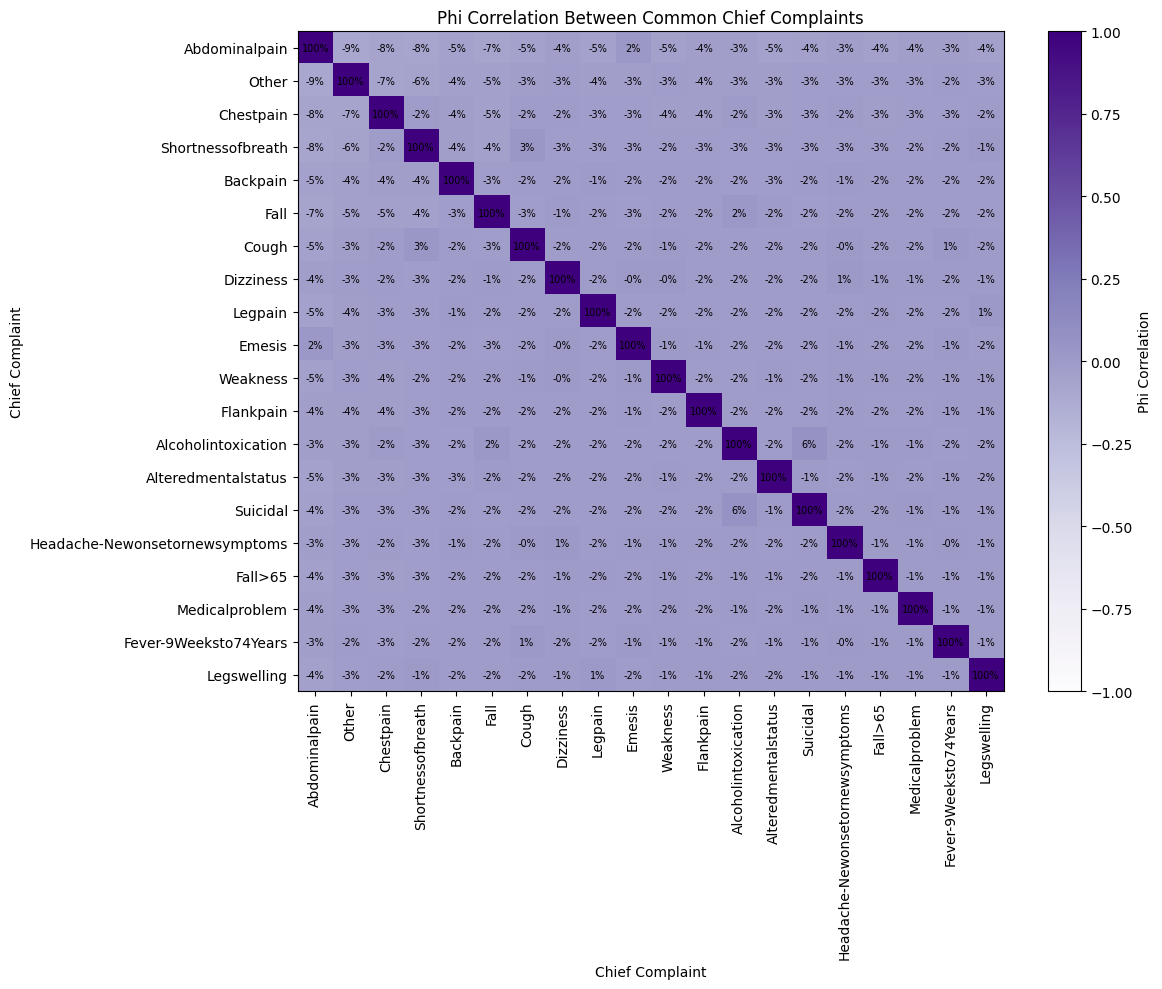

In [164]:
# Heatmap of phi correlations between CCs
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    cc_phi_corr,
    aspect="auto",
    cmap="Purples",
    vmin=-1,
    vmax=1
)

ax.set_title("Phi Correlation Between Common Chief Complaints")
ax.set_xlabel("Chief Complaint")
ax.set_ylabel("Chief Complaint")

# Clean complaint labels for readability
clean_labels = [
    col.replace("cc_", "").replace("_", " ").title()
    for col in top_cc_cols
]

ax.set_xticks(range(len(top_cc_cols)))
ax.set_xticklabels(clean_labels, rotation=90)

ax.set_yticks(range(len(top_cc_cols)))
ax.set_yticklabels(clean_labels)
# Add phi correlation values inside each heatmap cell

for i in range(len(top_cc_cols)):
    for j in range(len(top_cc_cols)):
        value = cc_phi_corr.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value * 100:.0f}%",
            ha="center",
            va="center",
            fontsize=7
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Phi Correlation")

plt.tight_layout()
plt.show()

In [165]:
# Convert phi correlation matrix into a readable pair table
cc_phi_pairs = []

for i, col1 in enumerate(top_cc_cols):
    for col2 in top_cc_cols[i + 1:]:
        corr = cc_phi_corr.loc[col1, col2]

        if pd.notna(corr):
            cc_phi_pairs.append({
                "Complaint 1": col1,
                "Complaint 2": col2,
                "Phi Correlation": round(corr, 3)
            })

cc_phi_pairs = pd.DataFrame(cc_phi_pairs)

cc_phi_pairs = cc_phi_pairs.sort_values(
    "Phi Correlation",
    ascending=False
)

display(cc_phi_pairs.head(20))

,Complaint 1,Complaint 2,Phi Correlation
163,cc_alcoholintoxication,cc_suicidal,0.064
56,cc_shortnessofbreath,cc_cough,0.026
91,cc_fall,cc_alcoholintoxication,0.020
8,cc_abdominalpain,cc_emesis,0.020
134,cc_legpain,cc_legswelling,0.012
110,cc_cough,cc_fever-9weeksto74years,0.008
119,cc_dizziness,cc_headache-newonsetornewsymptoms,0.006
182,cc_headache-newonsetornewsymptoms,cc_fever-9weeksto74years,-0.001
107,cc_cough,cc_headache-newonsetornewsymptoms,-0.002
113,cc_dizziness,cc_emesis,-0.004


*Exploring the Correlation between CC and ESI*

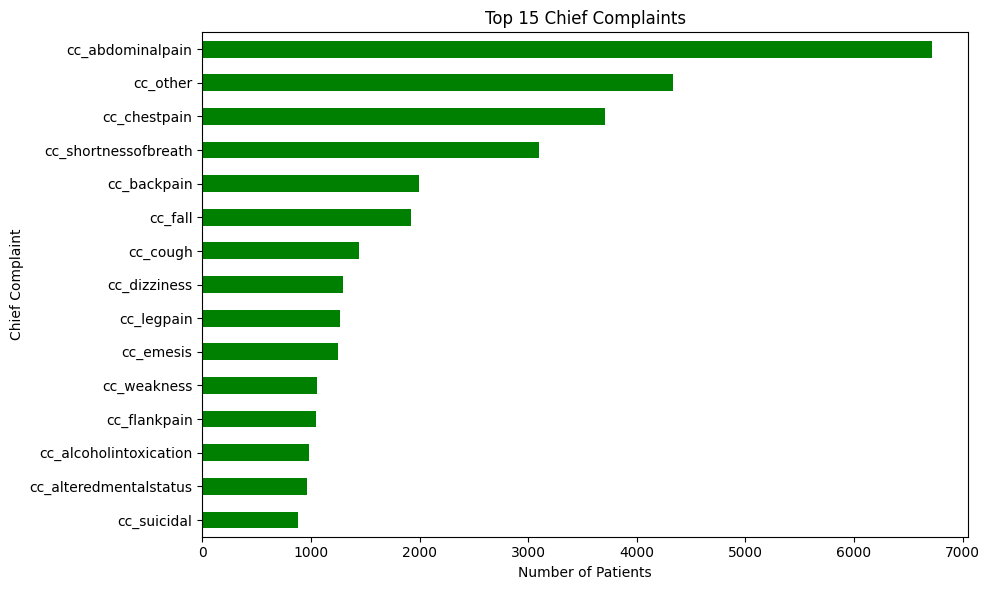

In [166]:
top15_complaints = chief_complaint_counts.head(15)

fig, ax = plt.subplots(figsize=(10, 6))

top15_complaints[::-1].plot.barh(ax=ax,color='Green')

ax.set_title("Top 15 Chief Complaints")
ax.set_xlabel("Number of Patients")
ax.set_ylabel("Chief Complaint")

plt.tight_layout()
plt.show()

In [167]:
#Exploring the ESI level distribution for the top 15 CC
top15_complaint_cols = top15_complaints.index

complaint_esi_rows = []

for complaint in top15_complaint_cols:
    patients_with_complaint = df[df[complaint] == 1]

    esi_distribution = (
        patients_with_complaint[TARGET]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )#Calculate the percentage distribution of ESI levels for each CC

    for esi_level, percentage in esi_distribution.items():
        complaint_esi_rows.append({
            "Chief Complaint": complaint,
            "ESI": int(esi_level),
            "Percentage": percentage
        })

complaint_esi_summary = pd.DataFrame(complaint_esi_rows)

display(complaint_esi_summary)

,Chief Complaint,ESI,Percentage
0,cc_abdominalpain,1,0.01
1,cc_abdominalpain,2,17.63
2,cc_abdominalpain,3,81.77
3,cc_abdominalpain,4,0.57
4,cc_abdominalpain,5,0.01
...,...,...,...
60,cc_alteredmentalstatus,3,13.33
61,cc_alteredmentalstatus,4,0.10
62,cc_suicidal,2,96.70
63,cc_suicidal,3,3.07


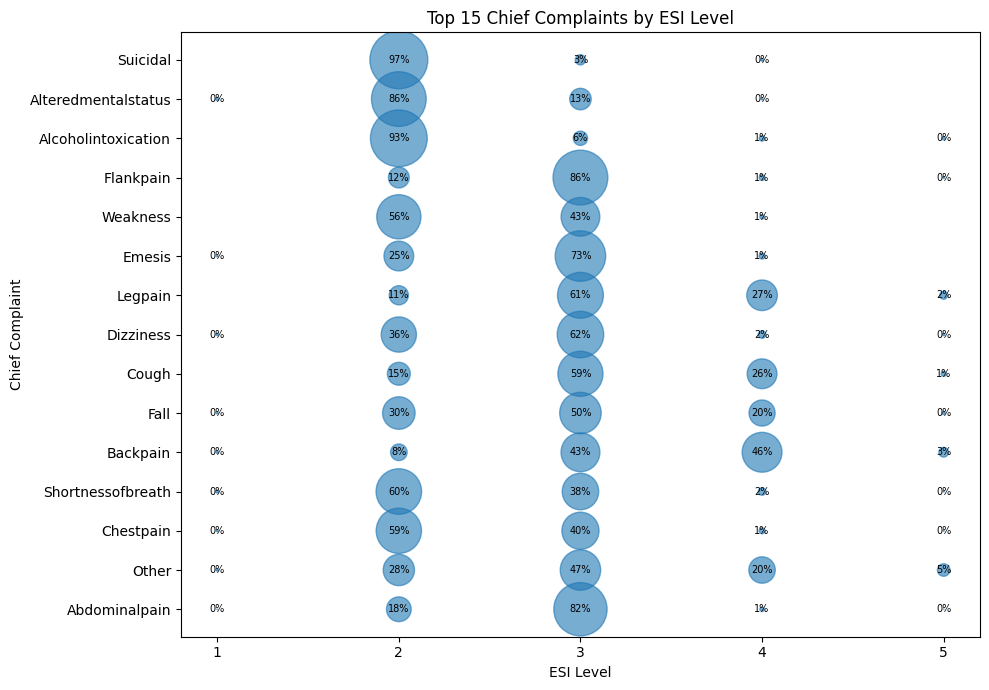

In [168]:
#Plotting a bubble map, each bubble represents the percentage of patients with a CC assigned to an ESI level

# Clean the chief complaint labels for easier reading.
complaint_esi_summary["Complaint Label"] = (
    complaint_esi_summary["Chief Complaint"]
    .str.replace("cc_", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

fig, ax = plt.subplots(figsize=(10, 7))

complaints = complaint_esi_summary["Complaint Label"].unique()
complaint_to_y = {complaint: i for i, complaint in enumerate(complaints)}

x = complaint_esi_summary["ESI"]
y = complaint_esi_summary["Complaint Label"].map(complaint_to_y)
sizes = complaint_esi_summary["Percentage"] * 18

ax.scatter(
    x,
    y,
    s=sizes,
    alpha=0.6
)#size of the bubbles

ax.set_title("Top 15 Chief Complaints by ESI Level")
ax.set_xlabel("ESI Level")
ax.set_ylabel("Chief Complaint")

ax.set_xticks(sorted(complaint_esi_summary["ESI"].unique()))
ax.set_yticks(range(len(complaints)))
ax.set_yticklabels(complaints)
#Add percentage labels inside each bubble for easier interpretation.
for _, row in complaint_esi_summary.iterrows():
    ax.text(
        row["ESI"],
        complaint_to_y[row["Complaint Label"]],
        f"{row['Percentage']:.0f}%",
        ha="center",
        va="center",
        fontsize=7
    )

plt.tight_layout()
plt.show()

In [169]:
# Spearman correlation between number of chief complaints and ESI
num_cc_esi_corr = df_clean[["num_chief_complaints", TARGET]].corr(
    method="spearman"
).iloc[0, 1]

print(f"Spearman correlation between number of chief complaints and ESI: {num_cc_esi_corr:.3f}")

Spearman correlation between number of chief complaints and ESI: -0.047


In [170]:
# Crosstab of number of CCs by ESI level
num_cc_esi_table = pd.crosstab(
    df_clean["num_chief_complaints"],
    df_clean[TARGET],
    normalize="index"
) * 100

display(num_cc_esi_table.round(2))

esi,1,2,3,4,5
num_chief_complaints,,,,,
0,0.00,22.22,33.33,35.19,9.26
1,0.14,31.88,49.07,16.60,2.31
2,0.14,37.75,47.69,12.99,1.43
3,0.14,30.94,54.68,12.89,1.36
4,0.00,29.63,66.67,3.70,0.00
5,0.00,18.18,72.73,9.09,0.00
6,0.00,0.00,100.00,0.00,0.00


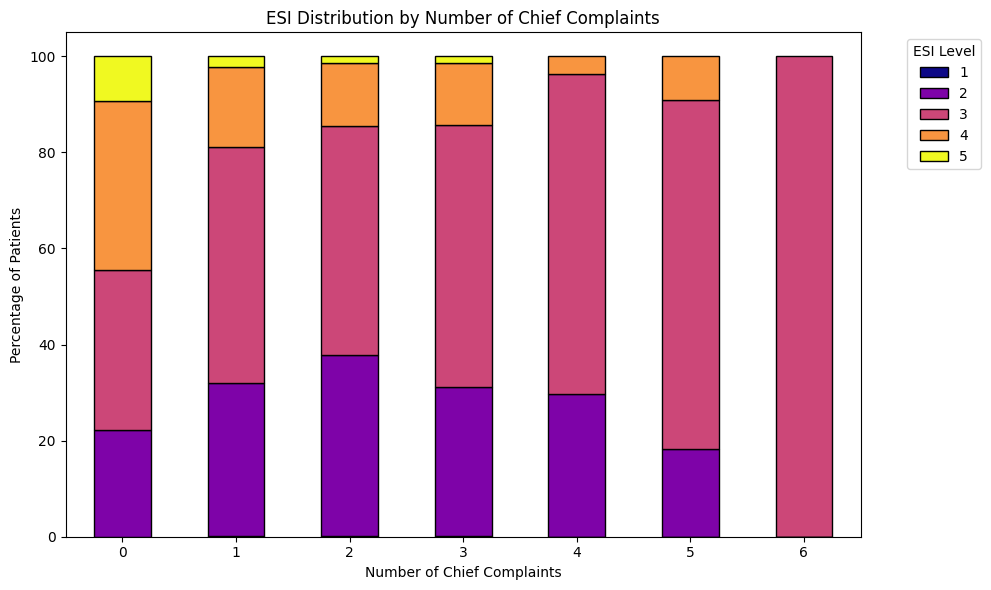

In [171]:
# Stacked bar chart of ESI distribution by number of CCs
fig, ax = plt.subplots(figsize=(10, 6))

num_cc_esi_table.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="plasma",
    edgecolor="black"
)

ax.set_title("ESI Distribution by Number of Chief Complaints")
ax.set_xlabel("Number of Chief Complaints")
ax.set_ylabel("Percentage of Patients")

ax.legend(
    title="ESI Level",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [172]:
#looing at the age distribution for the top 20 CC
top20_complaints = df_clean[fam["chief_complaints"]].sum().sort_values(ascending=False).head(20).index

complaint_by_age = df_clean.groupby("age_group")[top20_complaints].mean() * 100

display(complaint_by_age.round(2))

,cc_abdominalpain,cc_other,cc_chestpain,cc_shortnessofbreath,cc_backpain,cc_fall,cc_cough,cc_dizziness,cc_legpain,cc_emesis,cc_weakness,cc_flankpain,cc_alcoholintoxication,cc_alteredmentalstatus,cc_suicidal,cc_headache-newonsetornewsymptoms,cc_fall>65,cc_medicalproblem,cc_fever-9weeksto74years,cc_legswelling
age_group,,,,,,,,,,,,,,,,,,,,
Adult,14.11,7.91,7.27,4.32,4.02,2.43,2.54,2.04,2.36,2.47,1.00,2.26,2.43,0.81,2.18,1.82,0.01,1.26,1.45,1.03
Elderly,8.04,7.78,5.57,8.42,2.76,5.75,2.77,3.01,2.15,1.82,3.86,1.15,0.42,3.75,0.34,1.10,4.35,1.63,1.21,1.77


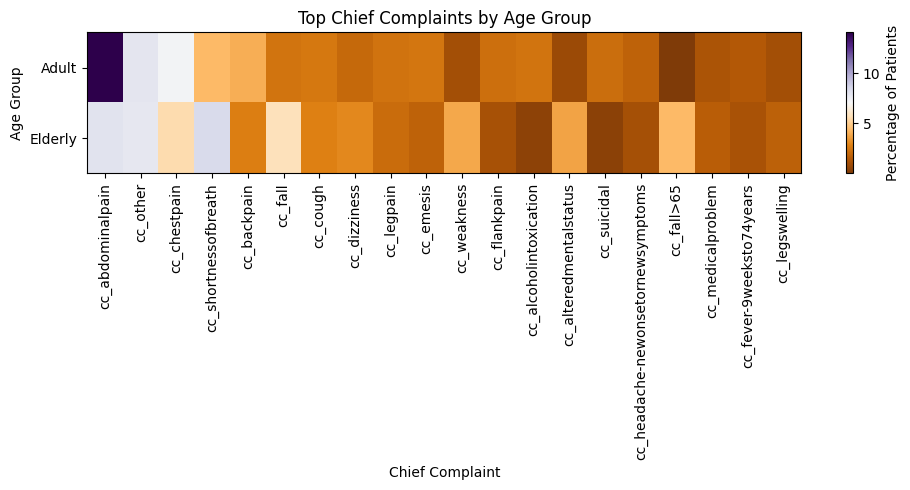

In [173]:
#Plotting a heatmap to explore the age distribution of the top 15 CC
fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(complaint_by_age, aspect="auto", cmap="PuOr")

ax.set_title("Top Chief Complaints by Age Group")
ax.set_xlabel("Chief Complaint")
ax.set_ylabel("Age Group")

ax.set_xticks(range(len(complaint_by_age.columns)))
ax.set_xticklabels(complaint_by_age.columns, rotation=90)

ax.set_yticks(range(len(complaint_by_age.index)))
ax.set_yticklabels(complaint_by_age.index)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Percentage of Patients")

plt.tight_layout()
plt.show()

*Exploring the correlation between CC and Vitals* 🔄

In [174]:
cc_vital_iqr_rows = []

for complaint in top20_complaints:
    for vital in fam["vitals"]:

        # Values for patients with the complaint
        present_values = df_clean.loc[df_clean[complaint] == 1, vital].dropna()

        # Values for patients without the complaint
        absent_values = df_clean.loc[df_clean[complaint] == 0, vital].dropna()

        # Calculate median and IQR for patients with the complaint
        present_median = present_values.median()
        present_q1 = present_values.quantile(0.25)
        present_q3 = present_values.quantile(0.75)
        present_iqr = present_q3 - present_q1

        # Calculate median and IQR for patients without the complaint
        absent_median = absent_values.median()
        absent_q1 = absent_values.quantile(0.25)
        absent_q3 = absent_values.quantile(0.75)
        absent_iqr = absent_q3 - absent_q1


        cc_vital_iqr_rows.append({
            "Chief Complaint": complaint,
            "Vital Sign": vital,
            "Median Difference": round(present_median - absent_median, 2)
        })

cc_vital_iqr_summary = pd.DataFrame(cc_vital_iqr_rows)

display(cc_vital_iqr_summary.head(20))

#display(cc_vital_iqr_summary)

,Chief Complaint,Vital Sign,Median Difference
0,cc_abdominalpain,triage_vital_hr,1.0
1,cc_abdominalpain,triage_vital_sbp,0.0
2,cc_abdominalpain,triage_vital_dbp,2.0
3,cc_abdominalpain,triage_vital_rr,0.0
4,cc_abdominalpain,triage_vital_o2,1.0
5,cc_abdominalpain,triage_vital_temp,0.1
6,cc_abdominalpain,triage_glucose,-2.0
7,cc_other,triage_vital_hr,1.0
8,cc_other,triage_vital_sbp,-1.0
9,cc_other,triage_vital_dbp,-1.0


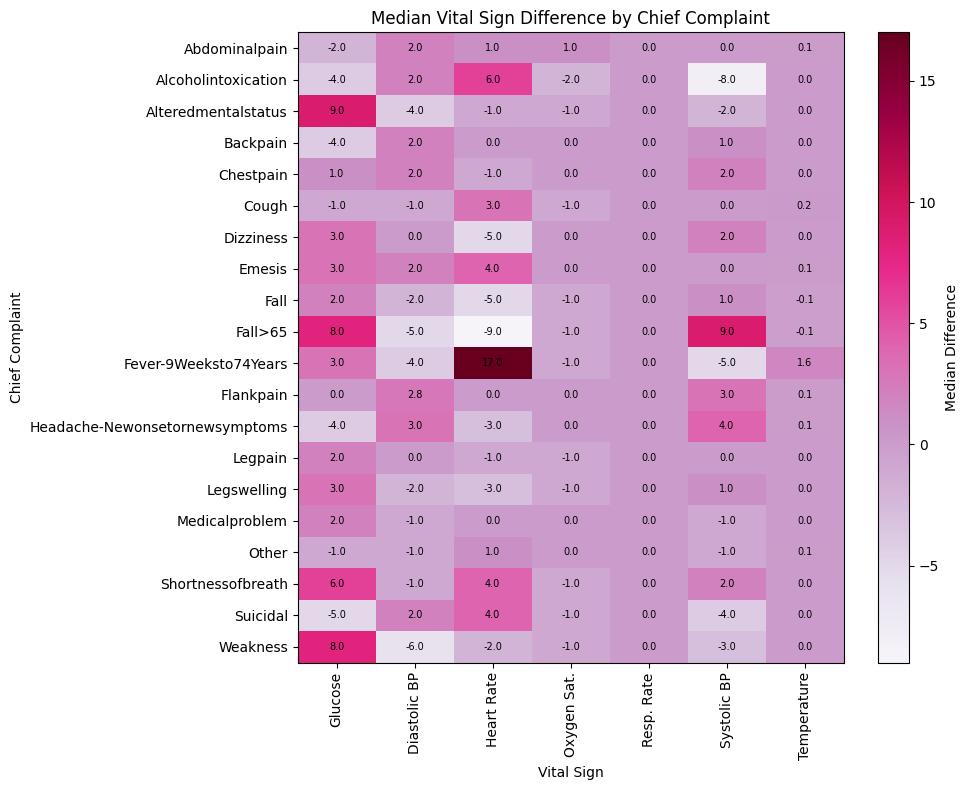

In [175]:
# heatmap plotting between CC and vitals
#what is the difference between vital signs amongst patients with a CC vs without the CC?
#for example what is the median difference in RR between patients with shortness of breath vs those without shortness of breath
cc_vital_median_heatmap = cc_vital_iqr_summary.pivot(
    index="Chief Complaint",
    columns="Vital Sign",
    values="Median Difference"
)


clean_complaint_labels = [
    complaint.replace("cc_", "").replace("_", " ").title()
    for complaint in cc_vital_median_heatmap.index
]


vital_labels = {
    "triage_vital_hr": "Heart Rate",
    "triage_vital_sbp": "Systolic BP",
    "triage_vital_dbp": "Diastolic BP",
    "triage_vital_rr": "Resp. Rate",
    "triage_vital_o2": "Oxygen Sat.",
    "triage_vital_temp": "Temperature",
    "triage_glucose": "Glucose"
}

clean_vital_labels = [
    vital_labels.get(vital, vital)
    for vital in cc_vital_median_heatmap.columns
]

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    cc_vital_median_heatmap,
    aspect="auto",
    cmap="PuRd"
)

ax.set_title("Median Vital Sign Difference by Chief Complaint")
ax.set_xlabel("Vital Sign")
ax.set_ylabel("Chief Complaint")

ax.set_xticks(range(len(clean_vital_labels)))
ax.set_xticklabels(clean_vital_labels, rotation=90)

ax.set_yticks(range(len(clean_complaint_labels)))
ax.set_yticklabels(clean_complaint_labels)


for i in range(len(cc_vital_median_heatmap.index)):
    for j in range(len(cc_vital_median_heatmap.columns)):
        value = cc_vital_median_heatmap.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=7
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Median Difference")

plt.tight_layout()
plt.show()

*Exploring Race+Gender+ESI Levels Correlation* 👩🧑

In [176]:
race_gender_esi_pct = pd.crosstab(
    [df["race"], df["gender"]],
    df[TARGET],
    normalize="index"
) * 100

display(race_gender_esi_pct.round(2))

esi                                                1.0    2.0    3.0    4.0  \
race                                      gender                              
American Indian or Alaska Native          Female  0.00  39.47  52.63   7.89   
                                          Male    0.00  25.00  53.57  14.29   
Asian                                     Female  0.00  37.04  43.21  13.58   
                                          Male    0.00  47.87  45.74   6.38   
Black or African American                 Female  0.07  26.26  50.47  20.63   
                                          Male    0.09  33.86  42.34  20.27   
Native Hawaiian or Other Pacific Islander Female  6.25  50.00  12.50  18.75   
                                          Male    0.00  50.00   0.00  25.00   
Other                                     Female  0.08  20.11  59.00  18.80   
                                          Male    0.05  30.01  46.43  20.45   
Patient Refused                           Female  0.00  20.95  58.10  16.21   
                                          Male    0.00  26.50  44.44  26.50   
Unknown                                   Female  0.00  19.57  58.70  17.39   
                                          Male    0.00  33.33  36.67  23.33   
White or Caucasian                        Female  0.15  34.10  51.14  13.02   
                                          Male    0.24  40.41  45.08  12.43   

esi                                                 5.0  
race                                      gender         
American Indian or Alaska Native          Female   0.00  
                                          Male     7.14  
Asian                                     Female   6.17  
                                          Male     0.00  
Black or African American                 Female   2.57  
                                          Male     3.45  
Native Hawaiian or Other Pacific Islander Female  12.50  
                                          Male    25.00  
Other                                     Female   2.01  
                                          Male     3.06  
Patient Refused                           Female   4.74  
                                          Male     2.56  
Unknown                                   Female   4.35  
                                          Male     6.67  
White or Caucasian                        Female   1.58  
                                          Male     1.83

*Exploring Age+Gender+ESI Levels Correlation* 👩🧑

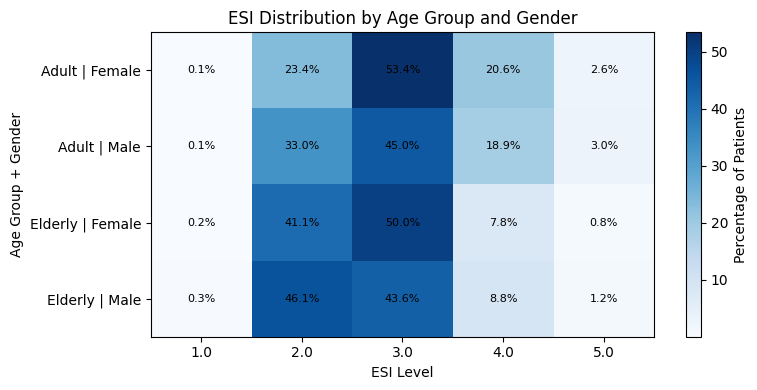

In [177]:
age_gender_esi_pct = pd.crosstab(
    [df["age_group"], df["gender"]],
    df[TARGET],
    normalize="index"
) * 100
#using a heatmap
fig, ax = plt.subplots(figsize=(8, max(4, len(age_gender_esi_pct) * 0.4)))

im = ax.imshow(age_gender_esi_pct, aspect="auto", cmap="Blues")

ax.set_title("ESI Distribution by Age Group and Gender")
ax.set_xlabel("ESI Level")
ax.set_ylabel("Age Group + Gender")

ax.set_xticks(range(len(age_gender_esi_pct.columns)))
ax.set_xticklabels(age_gender_esi_pct.columns)

ax.set_yticks(range(len(age_gender_esi_pct.index)))
ax.set_yticklabels([f"{idx[0]} | {idx[1]}" for idx in age_gender_esi_pct.index])

for i in range(len(age_gender_esi_pct.index)):
    for j in range(len(age_gender_esi_pct.columns)):
        ax.text(j, i, f"{age_gender_esi_pct.iloc[i, j]:.1f}%",
                ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Percentage of Patients")

plt.tight_layout()
plt.show()

*Exploring Insurance Fairness* 🖥

In [178]:
insurance_esi_pct = pd.crosstab(
    df["insurance_status"],
    df[TARGET],
    normalize="index"
) * 100

display(insurance_esi_pct.round(2))

esi,1.0,2.0,3.0,4.0,5.0
insurance_status,,,,,
Commercial,0.14,33.89,50.43,14.04,1.50
Medicaid,0.05,25.71,49.42,21.75,3.06
Medicare,0.24,41.00,47.63,9.77,1.35
Other,0.05,19.81,45.78,28.57,5.79
Self pay,1.15,40.23,55.17,3.45,0.00


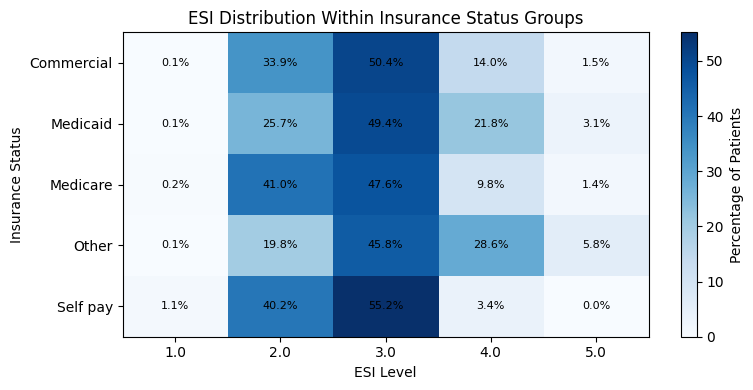

In [179]:
# is there a correlation between insurance and esi levels
fig, ax = plt.subplots(figsize=(8, max(4, len(insurance_esi_pct) * 0.5)))

im = ax.imshow(insurance_esi_pct, aspect="auto", cmap="Blues")

ax.set_title("ESI Distribution Within Insurance Status Groups")
ax.set_xlabel("ESI Level")
ax.set_ylabel("Insurance Status")

ax.set_xticks(range(len(insurance_esi_pct.columns)))
ax.set_xticklabels(insurance_esi_pct.columns)

ax.set_yticks(range(len(insurance_esi_pct.index)))
ax.set_yticklabels(insurance_esi_pct.index)

for i in range(len(insurance_esi_pct.index)):
    for j in range(len(insurance_esi_pct.columns)):
        ax.text(
            j,
            i,
            f"{insurance_esi_pct.iloc[i, j]:.1f}%",
            ha="center",
            va="center",
            fontsize=8
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Percentage of Patients")

plt.tight_layout()
plt.show()

*Exploring Arrival bias* 🚑


esi,1,2,3,4,5
arrivalmode,,,,,
Car,0.05,23.72,54.26,19.49,2.48
Other,0.19,45.19,44.07,8.33,2.22
Police,0.00,75.00,25.00,0.00,0.00
Public Transportation,0.00,14.00,52.29,29.14,4.57
Walk-in,0.05,21.34,48.93,25.59,4.10
Wheelchair,0.00,47.57,45.69,6.74,0.00
ambulance,0.32,50.66,42.73,5.73,0.56


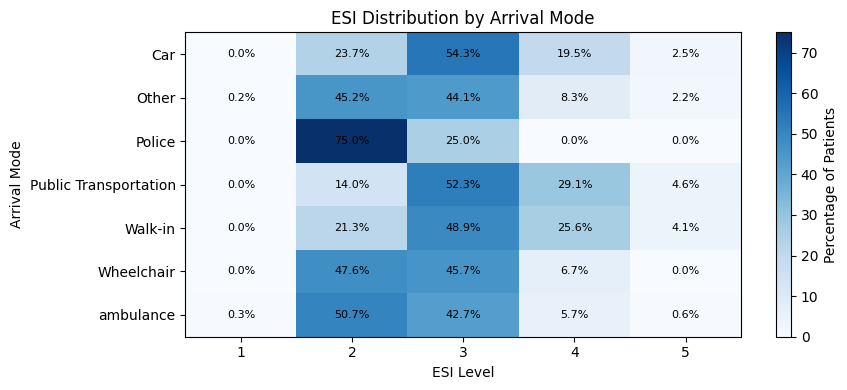

In [180]:
#is there a correlation between arrival mode and esi levels?
arrival_esi_pct = pd.crosstab(
    df_clean["arrivalmode"],
    df_clean[TARGET],
    normalize="index"
) * 100

display(arrival_esi_pct.round(2))
#using a heatmap to explore correlation

fig, ax = plt.subplots(figsize=(9, max(4, len(arrival_esi_pct) * 0.45)))

im = ax.imshow(arrival_esi_pct, aspect="auto", cmap="Blues")

ax.set_title("ESI Distribution by Arrival Mode")
ax.set_xlabel("ESI Level")
ax.set_ylabel("Arrival Mode")

ax.set_xticks(range(len(arrival_esi_pct.columns)))
ax.set_xticklabels(arrival_esi_pct.columns)

ax.set_yticks(range(len(arrival_esi_pct.index)))
ax.set_yticklabels(arrival_esi_pct.index)

for i in range(len(arrival_esi_pct.index)):
    for j in range(len(arrival_esi_pct.columns)):
        value = arrival_esi_pct.iloc[i, j]
        ax.text(j, i, f"{value:.1f}%", ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Percentage of Patients")

plt.tight_layout()
plt.show()